# -------------------------- DECISION TREE ---------------------------

**Objective:**

The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

**Tasks:**

1. Data Preparation:

    * Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

2. Exploratory Data Analysis (EDA):

    * Perform exploratory data analysis to understand the structure of the dataset.
    * Check for missing values, outliers, and inconsistencies in the data.
    * Visualize the distribution of features, including histograms, box plots, and correlation matrices.

3. Feature Engineering:

    * If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

4. Decision Tree Classification:

    * Split the dataset into training and testing sets (e.g., using an 80-20 split).
    * Implement a Decision Tree Classification model using a library like scikit-learn.
    * Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

5. Hyperparameter Tuning:

    * Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

6. Model Evaluation and Analysis:

    * Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
    * Visualize the decision tree structure to understand the rules learned by the model and identify important features

Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
2. What is the difference between the Label encoding and One-hot encoding?

***TASK 1. Data Preparation:***

  * Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [141]:
# ---------- *** STEP 1: DATA EXPLORATION *** -------------- #

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [142]:
df = pd.read_csv('heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,FALSE,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,FALSE,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,FALSE,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,FALSE,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,TRUE,1.5,flat,fixed defect,0


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [144]:
# Statistical Summary

df.describe()


,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


***TASK 2. Exploratory Data Analysis (EDA)***:

  * Perform exploratory data analysis to understand the structure of the dataset.
  * Check for missing values, outliers, and inconsistencies in the data.
  * Visualize the distribution of features, including histograms, box plots, and correlation matrices.

***TASK 3. Feature Engineering***:

  * If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [145]:
# ----------- *** STEP 2: Finding Missing Values, EDA and Imputing *** ------------- #

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


<function matplotlib.pyplot.show(close=None, block=None)>

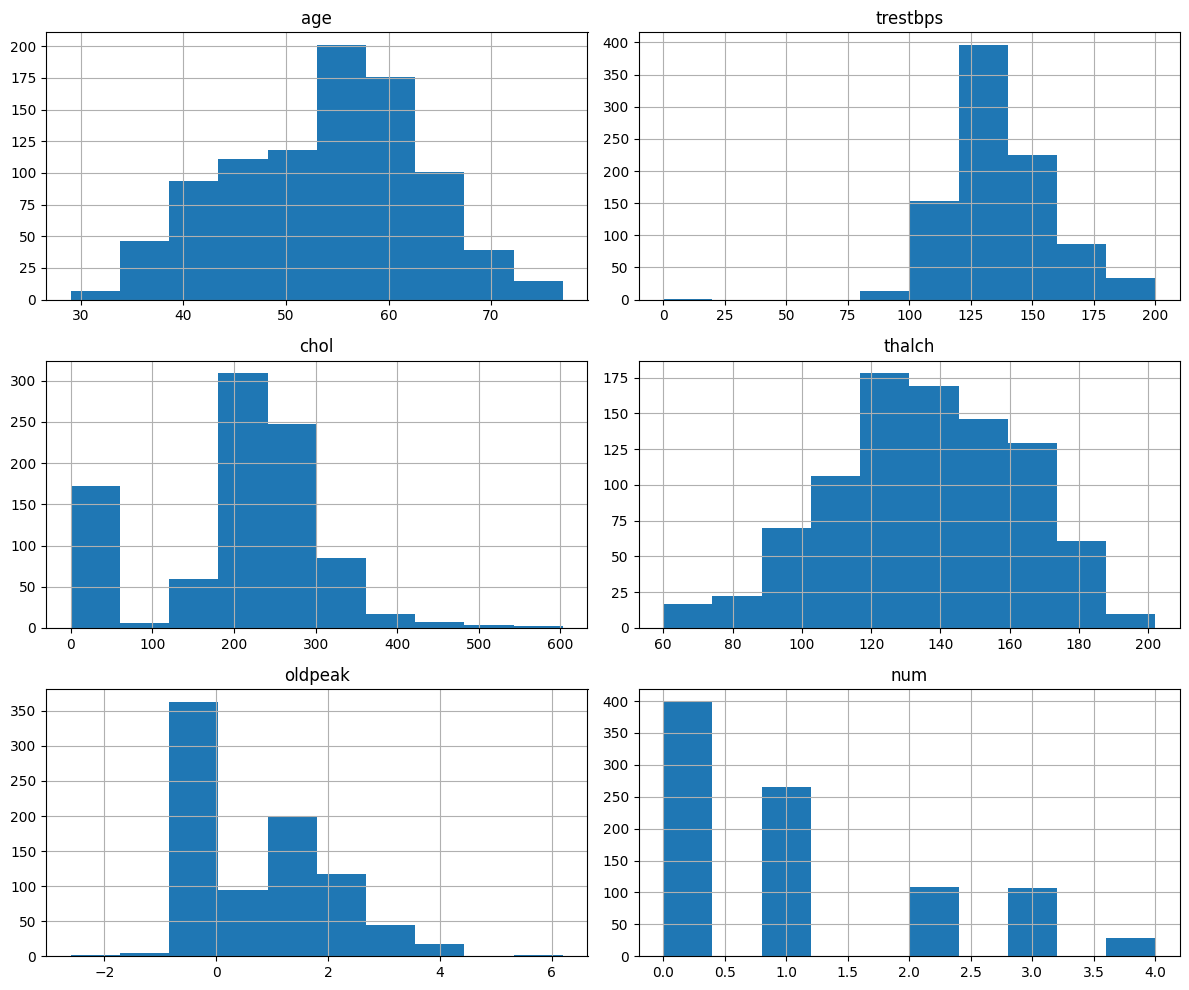

In [146]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show

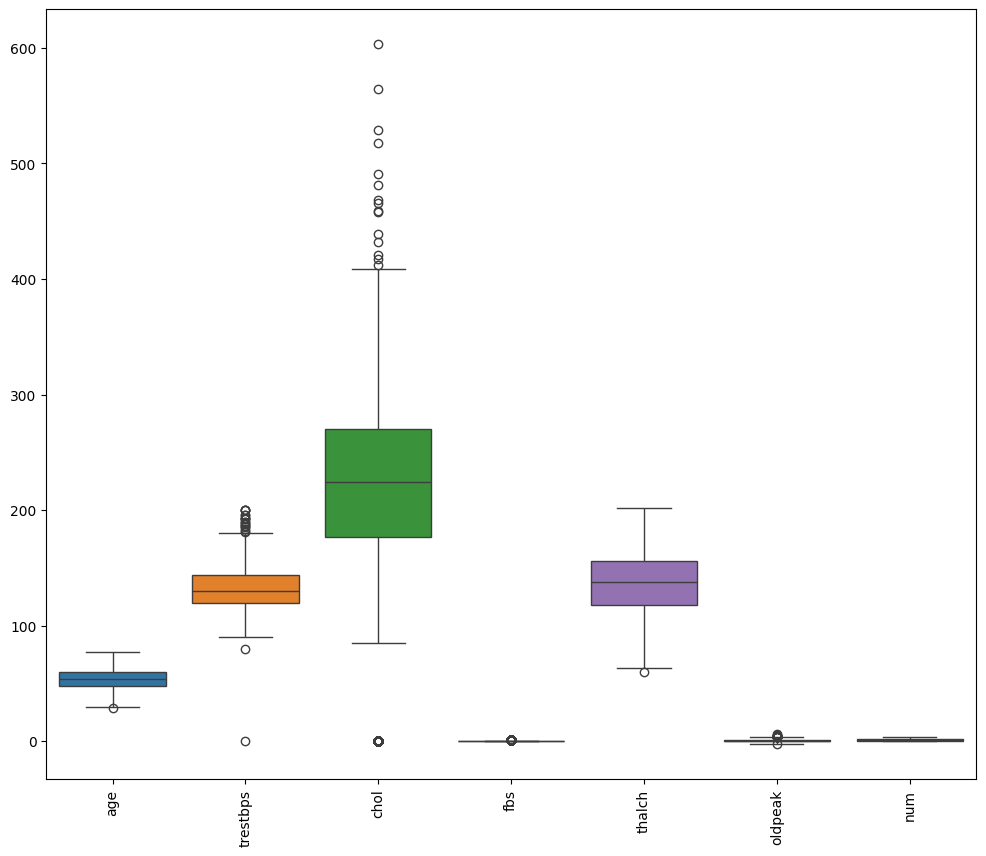

In [147]:
plt.figure(figsize=(12,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

1. Age:

  * Roughly normal distribution

  * Majority between 45-65 years

2. Cholesterol:

  * Right-skewed

  * High variability

  * Outliers present (values > 500)

3. Resting BP:

  * Slight right-skew

  * Outliers at higher BP values

4. Oldpeak:

  * Majority near 0-2

  * Negative values indicate anomalies

5. thalch:

  * Left-skewed

  * Patients generally have moderate max heart rate

In [148]:
cat_cols=df.select_dtypes(include=['object', 'bool']).columns

le=LabelEncoder()
for col in cat_cols:
    df[col]=le.fit_transform(df[col])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,0,2.3,0,0,0
1,41,1,1,135,203,0,1,132,0,0.0,1,0,0
2,57,1,0,140,192,0,1,148,0,0.4,1,0,0
3,52,1,3,118,186,0,0,190,0,0.0,1,0,0
4,57,1,0,110,201,0,1,126,1,1.5,1,0,0


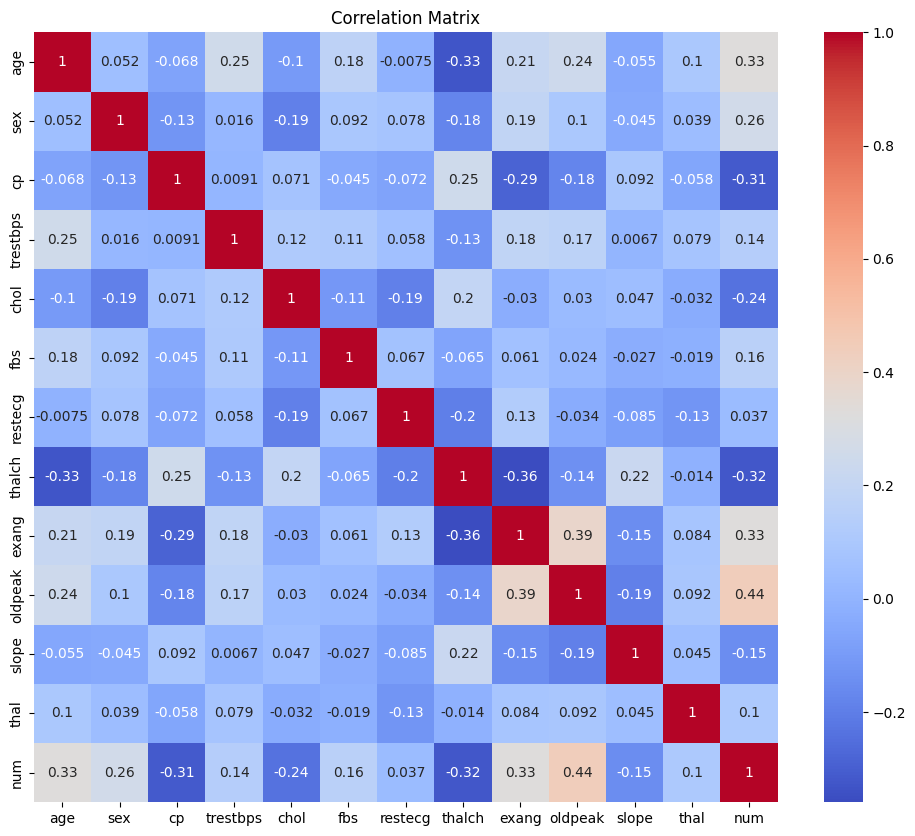

In [149]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [150]:
# Handling Missing Values

df.fillna(df.median(numeric_only=True), inplace=True)

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    int64  
 2   cp        908 non-null    int64  
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    int64  
 6   restecg   908 non-null    int64  
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    int64  
 9   oldpeak   908 non-null    float64
 10  slope     908 non-null    int64  
 11  thal      908 non-null    int64  
 12  num       908 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 92.3 KB


In [152]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,0,2.3,0,0,0
1,41,1,1,135,203,0,1,132,0,0.0,1,0,0
2,57,1,0,140,192,0,1,148,0,0.4,1,0,0
3,52,1,3,118,186,0,0,190,0,0.0,1,0,0
4,57,1,0,110,201,0,1,126,1,1.5,1,0,0


In [159]:
# Standard Scaler for numerical column
num_cols=df.select_dtypes(include=['int64', 'float64']).columns
ss=StandardScaler()
df[num_cols]=ss.fit_transform(df[num_cols])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1.006027,0.514416,2.320276,0.567394,0.281297,1.976894,-1.561352,0.524183,-0.787899,1.354403,-1.672770,-1.523681,-0.881977
1,-1.397560,0.514416,0.232258,0.076967,0.013526,-0.505844,0.013879,-0.147705,-0.787899,-0.815718,-0.224843,-1.523681,-0.881977
2,0.350503,0.514416,-0.811752,0.322181,-0.084656,-0.505844,0.013879,0.449529,-0.787899,-0.438305,-0.224843,-1.523681,-0.881977
3,-0.195767,0.514416,2.320276,-0.756760,-0.138211,-0.505844,-1.561352,2.017268,-0.787899,-0.815718,-0.224843,-1.523681,-0.881977
4,0.350503,0.514416,-0.811752,-1.149102,-0.004325,-0.505844,0.013879,-0.371668,0.961275,0.599578,-0.224843,-1.523681,-0.881977


***TASK 4. Decision Tree Classification***:

  * Split the dataset into training and testing sets (e.g., using an 80-20 split).
  * Implement a Decision Tree Classification model using a library like scikit-learn.
  * Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [160]:
# Split Data

X = df.drop('num', axis=1)
y = df['num']

y=y.apply(lambda x:1 if x>0 else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [161]:
# Decision Tree

dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [165]:
# --------- Model Evaluation ---------------
y_pred = dt.predict(X_test)
y_pred_proba=dt.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# For binary classification, roc_auc_score expects probabilities of the positive class only.
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')
print(f'ROC-AUC: {roc_auc:.2f}')

print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.74
Precision: 0.47
Recall: 0.47
F1-Score: 0.47
ROC-AUC: 0.65

Confusion Matrix:
 [[113  24]
 [ 24  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82       137
           1       0.47      0.47      0.47        45

    accuracy                           0.74       182
   macro avg       0.65      0.65      0.65       182
weighted avg       0.74      0.74      0.74       182



***TASK 5. Hyperparameter Tuning***:

  * Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

***TASK 6. Model Evaluation and Analysis***:

  * Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
  * Visualize the decision tree structure to understand the rules learned by the model and identify important features

In [176]:
# Hyperparameter Tuning

param_grid = {
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [177]:
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print('Best Parameters:', best_params)
print('Best Model:', best_model)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best Model: DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10,
                       random_state=42)


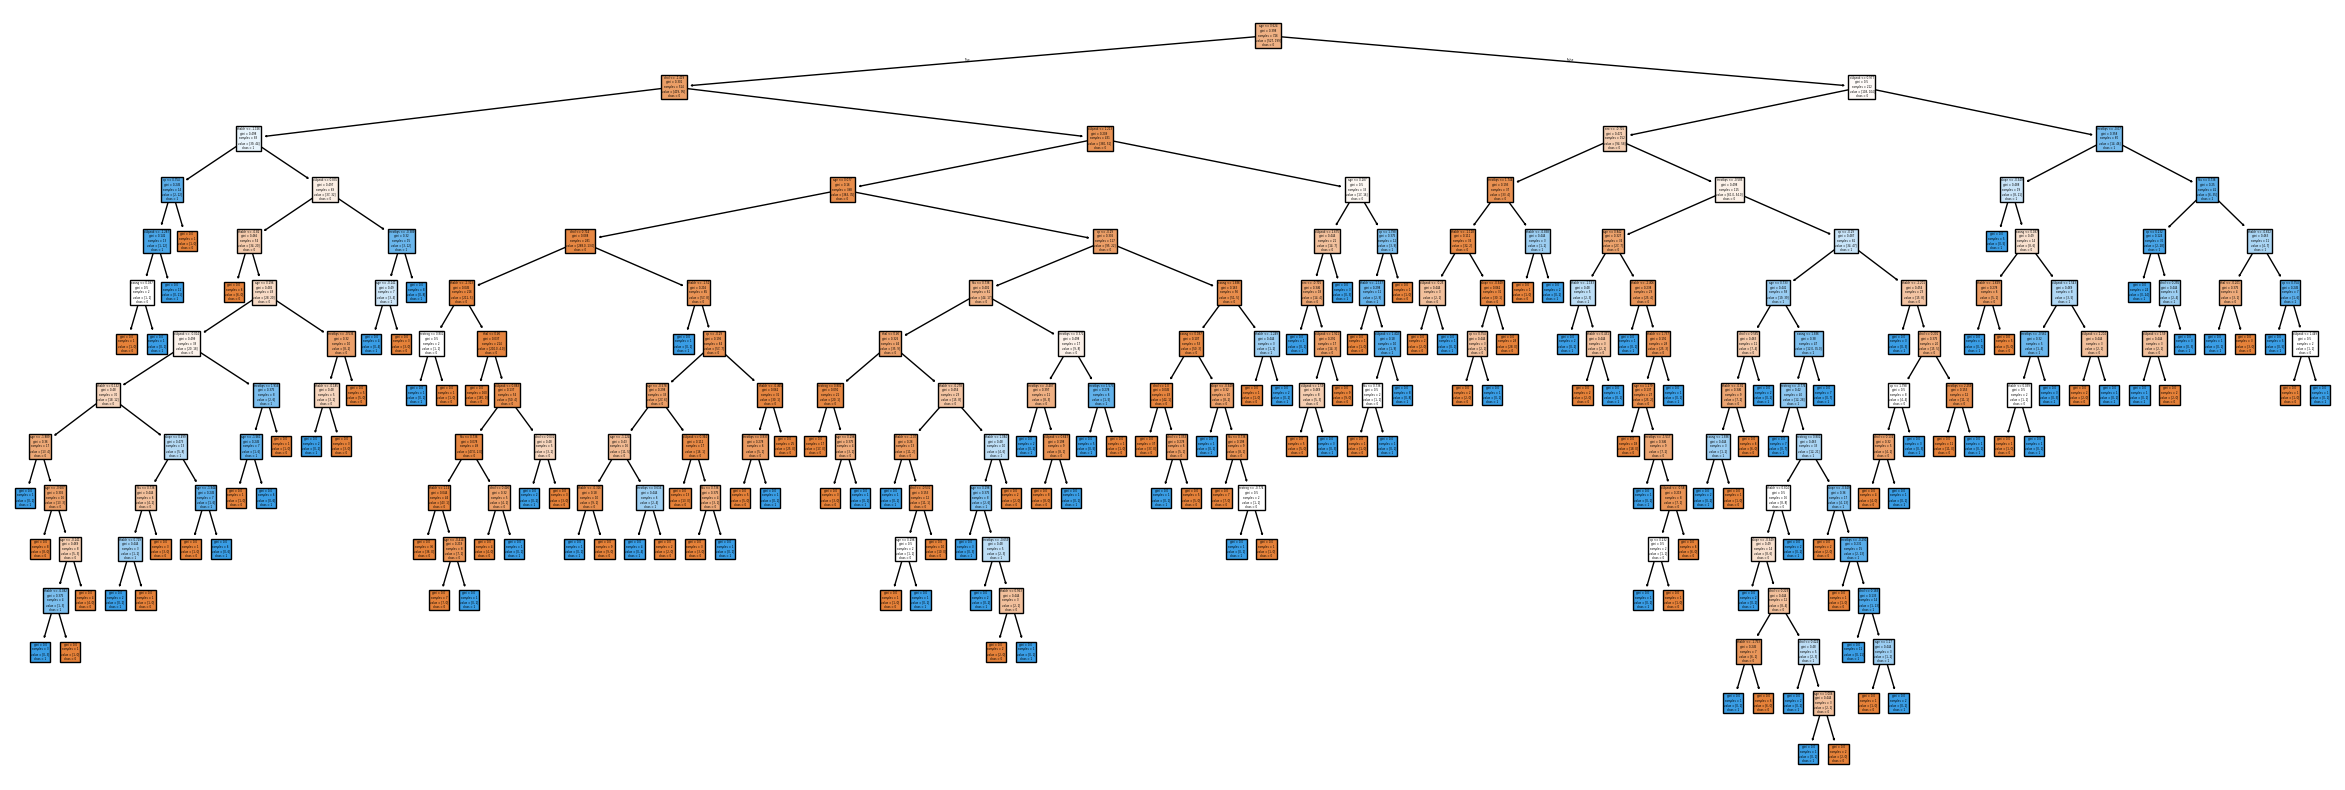

In [169]:
# Plot Decision Tree

plt.figure(figsize=(30,10))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=['0', '1'])
plt.show()

In [170]:
n_nodes = dt.tree_.node_count
depth = dt.tree_.max_depth

print(f'Number of Nodes: {n_nodes}')
print(f'Depth of the Tree: {depth}')

Number of Nodes: 277
Depth of the Tree: 14


In [174]:
dt2=DecisionTreeClassifier(max_depth=5, criterion='entropy')
dt2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [175]:
dt2.score(X_train, y_train)
dt2.score(X_test, y_test)

print(f'Training Score: {dt2.score(X_train, y_train)}')
print(f'Testing Score: {dt2.score(X_test, y_test)}')

Training Score: 0.8333333333333334
Testing Score: 0.7197802197802198


In [178]:
dtr=DecisionTreeRegressor()
dtr.fit(X_train, y_train)

DecisionTreeRegressor()

In [179]:
dtr.score(X_train, y_train)
dtr.score(X_test, y_test)

print(f'Training Score: {dtr.score(X_train, y_train)}')
print(f'Testing Score: {dtr.score(X_test, y_test)}')

Training Score: 1.0
Testing Score: -0.4170316301703163


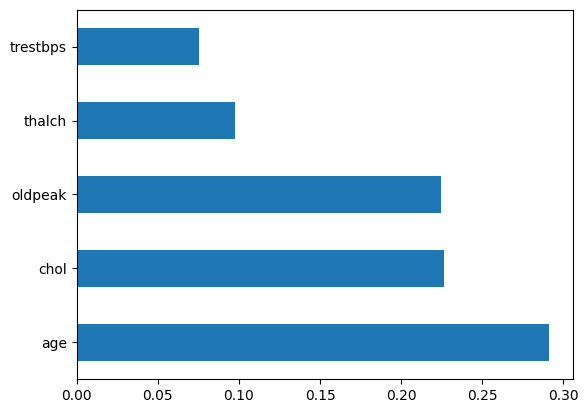

In [181]:
# Feature importances

imp=pd.Series(best_model.feature_importances_, index=X.columns)
imp.nlargest(5).plot(kind='barh')
plt.show()

Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
2. What is the difference between the Label encoding and One-hot encoding?

## Ans 1:

Common Hyperparameters iof Decision tree models are:

  * max_depth - prevents overfitting by controlling complexity
  * min_samples_split - higher values reduce overfitting
  * min_samples_leaf - Ensures leaves are not too small, improved stability
  * criterion - (gini or entropy) affects how splits are chosen, minor impact on accuracy
  * max_features - reduces variance, especially useful in ensemble trees
  * splitter - (best or ramdom) may improve generalization in noisy data

## Ans 2:

### Label Encoding:

  * Assigns a unique integer to each category
  * Categories are ordinal (low, high, medium)
  * Tree-based models (Decision trees and Random Forest)

### One-hot Encoding:

  * Creates binary columns for each category
  * Categories are nominal (no inherent order)
  * while using linear models or neural networks
